### Imports neccessary libraries and packages & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

##### Dataset load

In [3]:
raw_df = pd.read_csv("./ai_jobs_salaries_clean.csv")

print("Shape:", raw_df.shape)
print("*"*65)
print("Data types:", raw_df.dtypes)


Shape: (71913, 17)
*****************************************************************
Data types: work_year                 int64
experience_level            str
employment_type             str
job_title                   str
salary                    int64
salary_currency             str
salary_in_usd             int64
employee_residence          str
remote_ratio              int64
company_location            str
company_size                str
experience_level_label      str
employment_type_label       str
work_mode                   str
salary_outlier_flag        bool
role_family                 str
isco_group_hint             str
dtype: object


### Missing values and duplicates

In [5]:
print("Missing values per column:\n", raw_df.isna().sum())
print("\nDuplicate rows:", raw_df.duplicated().sum())
print("\nTarget summary (salary_in_usd):")
print(raw_df["salary_in_usd"].describe())

Missing values per column:
 work_year                     0
experience_level              0
employment_type               0
job_title                     0
salary                        0
salary_currency               0
salary_in_usd                 0
employee_residence            0
remote_ratio                  0
company_location              0
company_size                  0
experience_level_label        0
employment_type_label         0
work_mode                     0
salary_outlier_flag           0
role_family                   0
isco_group_hint           40540
dtype: int64

Duplicate rows: 0

Target summary (salary_in_usd):
count     71913.000000
mean     151161.252625
std       77329.594122
min       15000.000000
25%       96000.000000
50%      138750.000000
75%      190315.000000
max      800000.000000
Name: salary_in_usd, dtype: float64


##### Dataset description table

In [8]:
# Dataset description table 

dataset_description = pd.DataFrame([
    ("no of total samples", raw_df.shape[0]),
    ("no of total features", raw_df.shape[1] - 1),
    ("target column", "salary_in_usd"),
    ("missing_values_total", int(raw_df.isna().sum().sum())),
    ("duplicate_rows", int(raw_df.duplicated().sum())),
], columns=["item", "value"])

dataset_description

,item,value
0,no of total samples,71913
1,no of total features,16
2,target column,salary_in_usd
3,missing_values_total,40540
4,duplicate_rows,0


In [9]:
# observe categorical columns

for c in ["experience_level", "employment_type", "company_size", "remote_ratio", "work_year", "role_family"]:
    print(f"{c}: {raw_df[c].nunique()} unique values -> {raw_df[c].unique()[:8]}")

print("\njob_title unique values:", raw_df["job_title"].nunique())
print("company_location unique values:", raw_df["company_location"].nunique())
print("isco_group_hint missing:", raw_df["isco_group_hint"].isna().sum(), "/", len(raw_df))


experience_level: 4 unique values -> <StringArray>
['EX', 'SE', 'MI', 'EN']
Length: 4, dtype: str
employment_type: 4 unique values -> <StringArray>
['FT', 'PT', 'CT', 'FL']
Length: 4, dtype: str
company_size: 3 unique values -> <StringArray>
['M', 'L', 'S']
Length: 3, dtype: str
remote_ratio: 3 unique values -> [  0 100  50]
work_year: 6 unique values -> [2025 2024 2023 2022 2020 2021]
role_family: 11 unique values -> <StringArray>
[   'Analytics Manager',       'Data Scientist', 'Other / Unclassified',
          'AI Engineer',         'Data Analyst',      'Computer Vision',
        'Data Engineer',          'ML Engineer']
Length: 8, dtype: str

job_title unique values: 422
company_location unique values: 97
isco_group_hint missing: 40540 / 71913


### Feature Engineering & Preprocessing

**Columns dropped and rationale**:

- `salary`, `salary_currency` : pre-conversion salary figures used to derive `salary_in_usd` itself (leakage)

- `salary_outlier_flag` : computed directly from `salary_in_usd` (leakage)

- `experience_level_label`, `employment_type_label` : exact duplicates of `experience_level` / `employment_type`

- `work_mode` : redundant with `remote_ratio` (same information, re-coded)

- `job_title` : 422 unique values; `role_family` is a de-noised grouping of it

- `isco_group_hint` : 56% missing, no reliable imputation available

- `employee_residence` : highly collinear with `company_location` for this dataset

**Kept features:** `work_year`, `experience_level`, `employment_type`, `remote_ratio`, `company_size`, `role_family`, `company_location` (rare countries grouped into `'Other'`).

**Sampling:** Support Vector Regression scales poorly with sample size, so a **stratified random subsample of 10,000 rows** (stratified by `role_family` to preserve class balance) is drawn from the cleaned data for all modelling experiments below. This is disclosed as a methodological limitation in the accompanying paper.

In [10]:
def engineer_features(df):

    df = df.copy()
    df = df.drop_duplicates()
    df = df.dropna(subset=["salary_in_usd"])

    keep_cols = [
        "work_year", "experience_level", "employment_type", "remote_ratio",
        "company_size", "role_family", "company_location", "salary_in_usd",
    ]
    df = df[keep_cols].copy()

    # group rare company_location values into 'Other'
    top_values = df["company_location"].value_counts().nlargest(8).index
    df["company_location"] = df["company_location"].where(df["company_location"].isin(top_values), other="Other")

    df["remote_ratio"] = df["remote_ratio"].astype(int)
    df["work_year"] = df["work_year"].astype(int)
    return df


clean_df = engineer_features(raw_df)
print("Cleaned shape:", clean_df.shape)
clean_df.head()


Cleaned shape: (71913, 8)


,work_year,experience_level,employment_type,remote_ratio,company_size,role_family,company_location,salary_in_usd
0,2025,EX,FT,0,M,Analytics Manager,US,348516
1,2025,EX,FT,0,M,Analytics Manager,US,232344
2,2025,SE,FT,0,M,Data Scientist,US,145400
3,2025,SE,FT,0,M,Data Scientist,US,81600
4,2025,MI,FT,100,M,Other / Unclassified,US,160000


In [12]:
def stratified_subsample(df, n=10000, strat_col="role_family", random_state=42):
    
    if n >= len(df):
        return df
    frac = n / len(df)
    parts = [group.sample(frac=frac, random_state=random_state) for _, group in df.groupby(strat_col, sort=False)]
    sampled = pd.concat(parts, axis=0)
    return sampled.sample(frac=1.0, random_state=random_state).reset_index(drop=True)


sampled_df = stratified_subsample(clean_df)
print("Sampled shape:", sampled_df.shape)
print(sampled_df["role_family"].value_counts(normalize=True).round(3))


Sampled shape: (9999, 8)
role_family
Other / Unclassified    0.564
Data Analyst            0.116
Data Engineer           0.101
Data Scientist          0.100
ML Engineer             0.051
Research Scientist      0.040
AI Engineer             0.017
Analytics Manager       0.007
AI Architect            0.003
Computer Vision         0.002
NLP                     0.000
Name: proportion, dtype: float64


In [13]:
def build_design_matrix(df):
    
    categorical_cols = ["experience_level", "employment_type", "company_size", "role_family", "company_location"]
    numeric_cols = ["work_year", "remote_ratio"]

    y = df["salary_in_usd"].to_numpy(dtype=float)
    X_num = df[numeric_cols].to_numpy(dtype=float)

    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")
    X_cat = ohe.fit_transform(df[categorical_cols])
    cat_feature_names = ohe.get_feature_names_out(categorical_cols)

    X = np.hstack([X_num, X_cat])
    feature_names = numeric_cols + list(cat_feature_names)
    numeric_idx = list(range(len(numeric_cols)))   # numeric columns are placed first
    return X, y, feature_names, numeric_idx


X, y, feature_names, numeric_idx = build_design_matrix(sampled_df)
print("Design matrix shape:", X.shape)
print("Number of engineered features:", len(feature_names))


Design matrix shape: (9999, 28)
Number of engineered features: 28


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (7999, 28)  Test shape: (2000, 28)


### Exploratory Data Analysis (EDA)

Summary statistics, target distribution, salary by experience level, salary by role family, and a correlation heatmap of numeric/ordinal features.

In [15]:
eda_summary = clean_df["salary_in_usd"].describe().to_frame(name="salary_in_usd")
eda_summary

,salary_in_usd
count,71913.000000
mean,151161.252625
std,77329.594122
min,15000.000000
25%,96000.000000
50%,138750.000000
75%,190315.000000
max,800000.000000


In [16]:
skew = clean_df["salary_in_usd"].skew()
print(f"Mean:   \${clean_df['salary_in_usd'].mean():,.0f}")
print(f"Median: \${clean_df['salary_in_usd'].median():,.0f}")
print(f"Std:    \${clean_df['salary_in_usd'].std():,.0f}")
print(f"Skewness: {skew:.2f}")
print(f"Range: \${clean_df['salary_in_usd'].min():,.0f} - \${clean_df['salary_in_usd'].max():,.0f}")


Mean:   \$151,161
Median: \$138,750
Std:    \$77,330
Skewness: 1.48
Range: \$15,000 - \$800,000


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
/var/folders/qh/qwbycz4d59792_lr1v_pflyw0000gn/T/ipykernel_7205/2154951651.py:2: SyntaxWarning: invalid escape sequence '\$'
  print(f"Mean:   \${clean_df['salary_in_usd'].mean():,.0f}")
/var/folders/qh/qwbycz4d59792_lr1v_pflyw0000gn/T/ipykernel_7205/2154951651.py:3: SyntaxWarning: invalid escape sequence '\$'
  print(f"Median: \${clean_df['salary_in_usd'].median():,.0f}")
/var/folders/qh/qwbycz4d59792_lr1v_pflyw0000gn/T/ipykernel_7205/2154951651.py:4: SyntaxWarning: invalid escape sequence '\$'

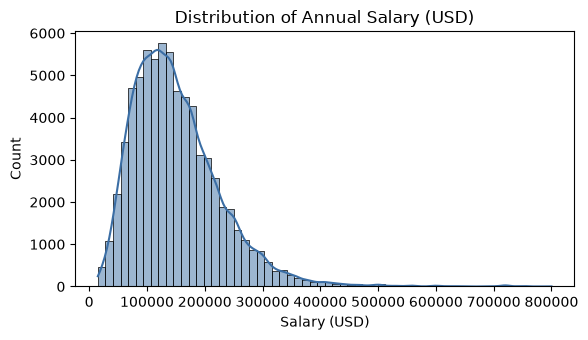

In [17]:
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.histplot(clean_df["salary_in_usd"], bins=60, kde=True, ax=ax, color="#3b6ea5")
ax.set_xlabel("Salary (USD)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Annual Salary (USD)")
fig.tight_layout()
fig.savefig("salary_dist.png")
plt.show()


/var/folders/qh/qwbycz4d59792_lr1v_pflyw0000gn/T/ipykernel_7205/476904084.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_df, x="experience_level", y="salary_in_usd", order=order, ax=ax, palette="Blues")


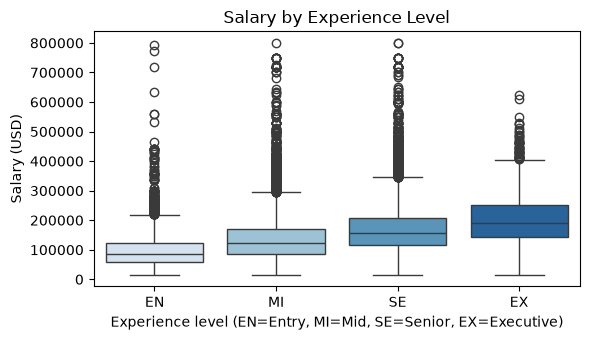

In [19]:
order = ["EN", "MI", "SE", "EX"]
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.boxplot(data=clean_df, x="experience_level", y="salary_in_usd", order=order, ax=ax, palette="Blues")
ax.set_xlabel("Experience level (EN=Entry, MI=Mid, SE=Senior, EX=Executive)")
ax.set_ylabel("Salary (USD)")
ax.set_title("Salary by Experience Level")
fig.tight_layout()
fig.savefig("Exp_vs_salary_boxplot.png")
plt.show()


/tmp/ipykernel_562/3813389087.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="role_family", y="salary_in_usd", order=order2, ax=ax, palette="viridis")
/tmp/ipykernel_562/3813389087.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")


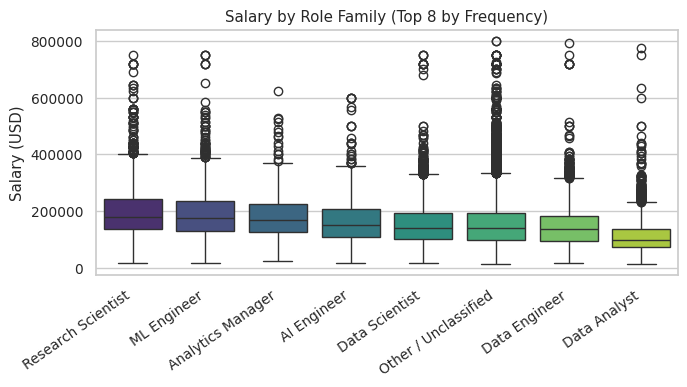

In [ ]:
top_roles = clean_df["role_family"].value_counts().nlargest(8).index
sub = clean_df[clean_df["role_family"].isin(top_roles)]
order2 = sub.groupby("role_family")["salary_in_usd"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=sub, x="role_family", y="salary_in_usd", order=order2, ax=ax, palette="viridis")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_xlabel("")
ax.set_ylabel("Salary (USD)")
ax.set_title("Salary by Role Family (Top 8 by Frequency)")
fig.tight_layout()
plt.show()


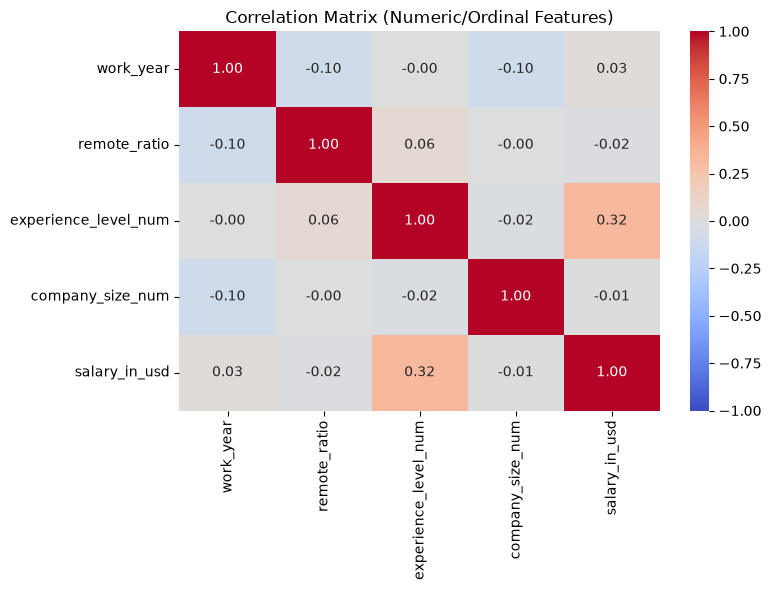

Experience-level correlation with salary: 0.32
Remote-ratio correlation with salary:      -0.02
Work-year correlation with salary:          0.03


In [20]:
corr_df = clean_df.copy()
exp_map = {"EN": 0, "MI": 1, "SE": 2, "EX": 3}
size_map = {"S": 0, "M": 1, "L": 2}
corr_df["experience_level_num"] = corr_df["experience_level"].map(exp_map)
corr_df["company_size_num"] = corr_df["company_size"].map(size_map)

num_cols = ["work_year", "remote_ratio", "experience_level_num", "company_size_num", "salary_in_usd"]
corr = corr_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Matrix (Numeric/Ordinal Features)")
fig.tight_layout()
fig.savefig("heatmap.png")
plt.show()

print(f"Experience-level correlation with salary: {corr.loc['experience_level_num','salary_in_usd']:.2f}")
print(f"Remote-ratio correlation with salary:      {corr.loc['remote_ratio','salary_in_usd']:.2f}")
print(f"Work-year correlation with salary:          {corr.loc['work_year','salary_in_usd']:.2f}")


### Model Training & Evaluation

Five regression algorithms (one more than the required minimum of four):

1. Linear Regression
2. Ridge Regression
3. Decision Tree Regressor
4. Support Vector Regression (SVR, RBF kernel)
5. MLP Regressor (neural network)

Each is evaluated on the test set (MAE, MSE, RMSE, R²) and via 5-fold cross-validation on the training set. Scale-sensitive models (Linear/Ridge/SVR/MLP) are trained on standardised numeric features; the Decision Tree is scale-invariant and trained on the raw numeric features and the full scaled-vs-unscaled sweep for every model is covered separately in Section 6.

In [21]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}


def scale_numeric(X_train, X_test, numeric_idx):
    scaler = StandardScaler()
    X_train_s, X_test_s = X_train.copy(), X_test.copy()
    X_train_s[:, numeric_idx] = scaler.fit_transform(X_train[:, numeric_idx])
    X_test_s[:, numeric_idx] = scaler.transform(X_test[:, numeric_idx])
    return X_train_s, X_test_s


X_train_scaled, X_test_scaled = scale_numeric(X_train, X_test, numeric_idx)

MODELS = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "SVR (RBF)": SVR(kernel="rbf", C=10, gamma="scale"),
    "MLP Regressor": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=800,
                                random_state=42, early_stopping=True),
}


In [22]:
test_results = []
cv_results = []
predictions = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in MODELS.items():
    use_scaled = name in ("SVR (RBF)", "MLP Regressor", "Linear Regression", "Ridge Regression")
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled if use_scaled else X_test

    t0 = time.time()
    model.fit(Xtr, y_train)
    fit_time = time.time() - t0

    y_pred = model.predict(Xte)
    predictions[name] = y_pred
    metrics = evaluate(y_test, y_pred)
    metrics["Model"] = name
    metrics["Fit time (s)"] = fit_time
    test_results.append(metrics)

    cv = cross_validate(
        model, Xtr, y_train, cv=kf,
        scoring={"r2": "r2", "neg_mae": "neg_mean_absolute_error", "neg_rmse": "neg_root_mean_squared_error"},
        n_jobs=1,
    )
    cv_results.append({
        "Model": name,
        "CV R2 mean": cv["test_r2"].mean(),
        "CV R2 std": cv["test_r2"].std(),
        "CV MAE mean": -cv["test_neg_mae"].mean(),
        "CV RMSE mean": -cv["test_neg_rmse"].mean(),
    })
    print(f"{name:20s} | test R2={metrics['R2']:.3f}  MAE={metrics['MAE']:,.0f}  "
          f"RMSE={metrics['RMSE']:,.0f}  (fit {fit_time:.2f}s)")

test_df = pd.DataFrame(test_results)[["Model", "MAE", "MSE", "RMSE", "R2", "Fit time (s)"]]
cv_df = pd.DataFrame(cv_results)


Linear Regression    | test R2=0.219  MAE=51,011  RMSE=72,032  (fit 0.04s)
Ridge Regression     | test R2=0.220  MAE=50,993  RMSE=72,003  (fit 0.01s)
Decision Tree        | test R2=0.216  MAE=51,197  RMSE=72,161  (fit 0.01s)
SVR (RBF)            | test R2=-0.026  MAE=58,644  RMSE=82,543  (fit 1.35s)
MLP Regressor        | test R2=0.215  MAE=51,309  RMSE=72,232  (fit 1.66s)


In [23]:
print("Test-set results:")
display(test_df.sort_values("R2", ascending=False).reset_index(drop=True))

Test-set results:


,Model,MAE,MSE,RMSE,R2,Fit time (s)
0,Ridge Regression,50993.205158,5.184431e+09,72002.995938,0.219606,0.007105
1,Linear Regression,51010.882531,5.188606e+09,72031.980952,0.218977,0.035245
2,Decision Tree,51197.117013,5.207200e+09,72160.932931,0.216179,0.013619
3,MLP Regressor,51308.527853,5.217460e+09,72231.987221,0.214634,1.658667
4,SVR (RBF),58643.507228,6.813280e+09,82542.593650,-0.025579,1.353281


In [24]:
print("5-fold cross-validation results:")
display(cv_df.sort_values("CV R2 mean", ascending=False).reset_index(drop=True))

5-fold cross-validation results:


,Model,CV R2 mean,CV R2 std,CV MAE mean,CV RMSE mean
0,Ridge Regression,0.214701,0.020233,50104.802430,68904.421039
1,Linear Regression,0.214442,0.020512,50114.463174,68915.799623
2,MLP Regressor,0.207996,0.017555,50443.206023,69196.353838
3,Decision Tree,0.196206,0.019331,50551.930770,69701.016455
4,SVR (RBF),-0.020656,0.006144,57171.340107,78535.164317


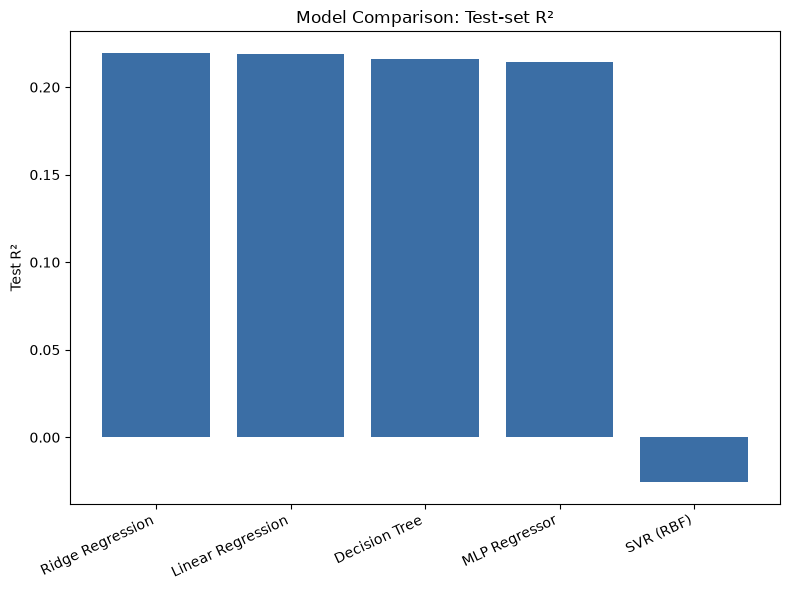

In [25]:
order = test_df.sort_values("R2", ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(order["Model"], order["R2"], color="#3b6ea5")
ax.set_ylabel("Test R²")
ax.set_title("Model Comparison: Test-set R²")
plt.xticks(rotation=25, ha="right")
fig.tight_layout()
fig.savefig("model_comparison.jpg")
plt.show()


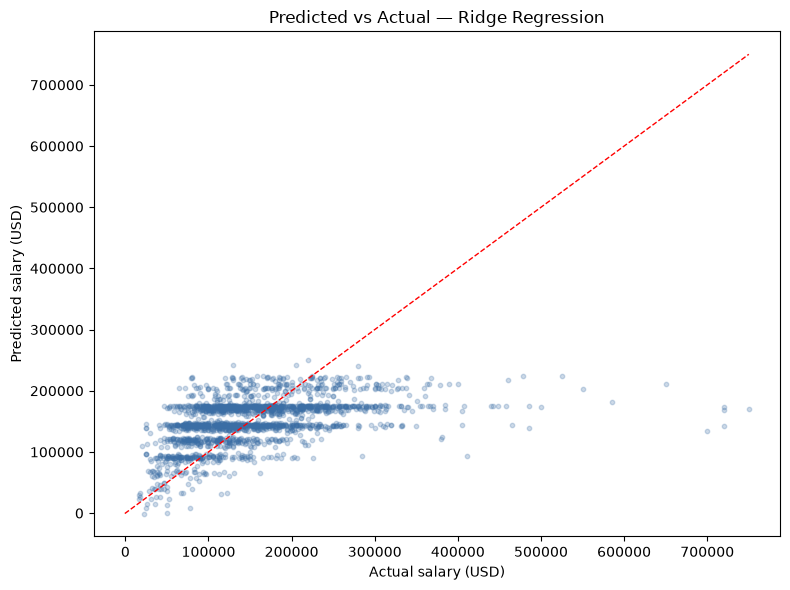

Best model on held-out test set: Ridge Regression


In [27]:
best_name = test_df.sort_values("R2", ascending=False).iloc[0]["Model"]
y_pred_best = predictions[best_name]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_best, alpha=0.25, s=10, color="#3b6ea5")
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("Actual salary (USD)")
ax.set_ylabel("Predicted salary (USD)")
ax.set_title(f"Predicted vs Actual — {best_name}")
fig.tight_layout()
fig.savefig("Predicted_vs_actual_salary.jpg")
plt.show()

print("Best model on held-out test set:", best_name)


### Comparative Study: Effect of Feature Scaling

Every algorithm is trained twice on identical train/test splits: once with the numeric features (`work_year`, `remote_ratio`) left in raw units, and once with those same features standardised. The one-hot categorical columns (already 0/1) are unchanged in both conditions, isolating the effect of scaling to the numeric features only.

In [28]:
def fresh_models():
    return {
        "Linear Regression": LinearRegression(),
        "Ridge Regression": Ridge(alpha=1.0, random_state=42),
        "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
        "SVR (RBF)": SVR(kernel="rbf", C=10, gamma="scale"),
        "MLP Regressor": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=800,
                                    random_state=42, early_stopping=True),
    }


scaling_rows = []
for name in fresh_models().keys():
    for condition, Xtr, Xte in [("Unscaled", X_train, X_test), ("Scaled", X_train_scaled, X_test_scaled)]:
        model = fresh_models()[name]
        model.fit(Xtr, y_train)
        y_pred = model.predict(Xte)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        scaling_rows.append({"Model": name, "Condition": condition, "MAE": mae, "RMSE": rmse, "R2": r2})

scaling_df = pd.DataFrame(scaling_rows)
pivot = scaling_df.pivot(index="Model", columns="Condition", values=["MAE", "RMSE", "R2"])
display(pivot)


MAE                        RMSE                \
Condition                Scaled      Unscaled        Scaled      Unscaled   
Model                                                                       
Decision Tree      51197.117013  51197.117013  72160.932931  72160.932931   
Linear Regression  51010.882531  51010.882531  72031.980952  72031.980952   
MLP Regressor      51308.527853  59818.204755  72231.987221  81239.489362   
Ridge Regression   50993.205158  50993.209536  72002.995938  72003.001032   
SVR (RBF)          58643.507228  58971.697335  82542.593650  82917.318009   

                         R2            
Condition            Scaled  Unscaled  
Model                                  
Decision Tree      0.216179  0.216179  
Linear Regression  0.218977  0.218977  
MLP Regressor      0.214634  0.006547  
Ridge Regression   0.219606  0.219606  
SVR (RBF)         -0.025579 -0.034912

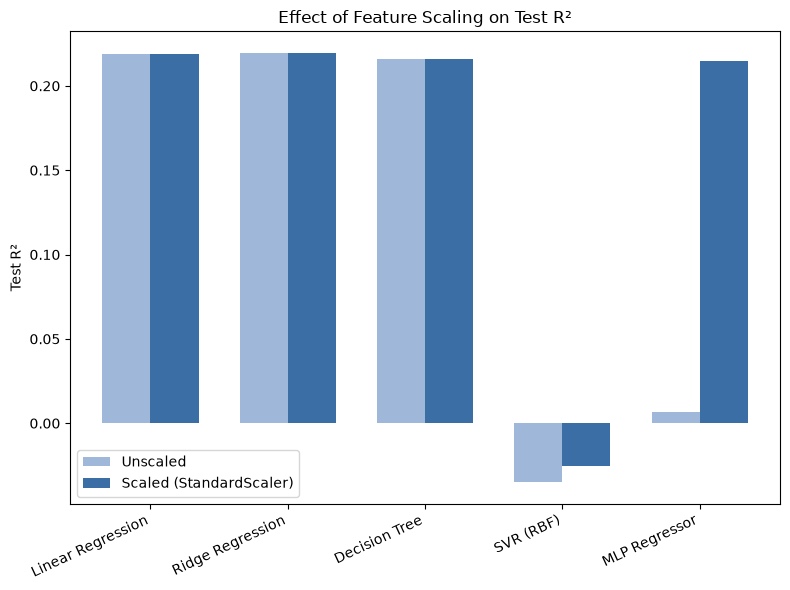

Key finding: MLP Regressor test R2 rises from 0.007 (unscaled) to 0.215 (scaled).
Linear/Ridge/Decision Tree are essentially unaffected by scaling.


In [29]:
models_list = list(fresh_models().keys())
unscaled_r2 = [scaling_df[(scaling_df.Model == m) & (scaling_df.Condition == "Unscaled")]["R2"].values[0] for m in models_list]
scaled_r2 = [scaling_df[(scaling_df.Model == m) & (scaling_df.Condition == "Scaled")]["R2"].values[0] for m in models_list]

x = np.arange(len(models_list))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width / 2, unscaled_r2, width, label="Unscaled", color="#9fb8d9")
ax.bar(x + width / 2, scaled_r2, width, label="Scaled (StandardScaler)", color="#3b6ea5")
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=25, ha="right")
ax.set_ylabel("Test R²")
ax.set_title("Effect of Feature Scaling on Test R²")
ax.legend()
fig.tight_layout()
fig.savefig("effect_of_feature_scalling.jpg")
plt.show()

print("Key finding: MLP Regressor test R2 rises from",
      f"{unscaled_r2[models_list.index('MLP Regressor')]:.3f} (unscaled) to",
      f"{scaled_r2[models_list.index('MLP Regressor')]:.3f} (scaled).")
print("Linear/Ridge/Decision Tree are essentially unaffected by scaling.")


### Hyperparameter Tuning (Bonus Part)

`GridSearchCV` (5-fold, scoring = negative MAE) for Ridge, Decision Tree and SVR.

In [30]:
grids = {
    "Ridge Regression": (Ridge(random_state=42),
                          {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}, X_train_scaled, X_test_scaled),
    "Decision Tree": (DecisionTreeRegressor(random_state=42),
                       {"max_depth": [4, 6, 8, 10, 14, None], "min_samples_leaf": [1, 5, 10]},
                       X_train, X_test),
    "SVR (RBF)": (SVR(kernel="rbf"),
                  {"C": [1, 10, 50, 100], "gamma": ["scale", 0.01, 0.1], "epsilon": [0.1, 1.0]},
                  X_train_scaled, X_test_scaled),
}

tuning_rows = []
for name, (estimator, param_grid, Xtr, Xte) in grids.items():
    gs = GridSearchCV(estimator, param_grid, scoring="neg_mean_absolute_error", cv=kf, n_jobs=-1)
    gs.fit(Xtr, y_train)
    best = gs.best_estimator_
    y_pred = best.predict(Xte)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    tuning_rows.append({
        "Model": name, "Best params": str(gs.best_params_),
        "CV best MAE": -gs.best_score_, "Test MAE": mae, "Test RMSE": rmse, "Test R2": r2,
    })
    print(f"{name}: best params={gs.best_params_}  test R2={r2:.3f}  test MAE={mae:,.0f}")

tuning_df = pd.DataFrame(tuning_rows)
tuning_df


Ridge Regression: best params={'alpha': 1.0}  test R2=0.220  test MAE=50,993
Decision Tree: best params={'max_depth': 8, 'min_samples_leaf': 5}  test R2=0.218  test MAE=51,320
SVR (RBF): best params={'C': 100, 'epsilon': 1.0, 'gamma': 'scale'}  test R2=0.018  test MAE=56,677


,Model,Best params,CV best MAE,Test MAE,Test RMSE,Test R2
0,Ridge Regression,{'alpha': 1.0},50104.802430,50993.205158,72002.995938,0.219606
1,Decision Tree,"{'max_depth': 8, 'min_samples_leaf': 5}",50174.762799,51319.826614,72088.527317,0.217751
2,SVR (RBF),"{'C': 100, 'epsilon': 1.0, 'gamma': 'scale'}",55444.694392,56676.512951,80774.111796,0.017896


### Feature-Subset Removal (Bonus)

Measures the marginal contribution of each categorical feature group by retraining the tuned Ridge model with one group removed at a time.

In [31]:
def build_X_y_subset(df, categorical_cols, numeric_cols):
    y_ = df["salary_in_usd"].to_numpy(dtype=float)
    X_num_ = df[numeric_cols].to_numpy(dtype=float) if numeric_cols else np.empty((len(df), 0))
    if categorical_cols:
        ohe_ = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")
        X_cat_ = ohe_.fit_transform(df[categorical_cols])
    else:
        X_cat_ = np.empty((len(df), 0))
    X_ = np.hstack([X_num_, X_cat_])
    return X_, y_


full_categorical = ["experience_level", "employment_type", "company_size", "role_family", "company_location"]
numeric_cols = ["work_year", "remote_ratio"]

scenarios = {
    "All features": full_categorical,
    "Without role_family": [c for c in full_categorical if c != "role_family"],
    "Without company_location": [c for c in full_categorical if c != "company_location"],
    "Without company_size": [c for c in full_categorical if c != "company_size"],
    "Experience level only": ["experience_level"],
}

ablation_rows = []
for label, cat_cols in scenarios.items():
    X_s, y_s = build_X_y_subset(sampled_df, cat_cols, numeric_cols)
    Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(X_s, y_s, test_size=0.2, random_state=42)

    scaler_s = StandardScaler()
    n_num = len(numeric_cols)
    Xtr_s[:, :n_num] = scaler_s.fit_transform(Xtr_s[:, :n_num])
    Xte_s[:, :n_num] = scaler_s.transform(Xte_s[:, :n_num])

    model_s = Ridge(alpha=1.0, random_state=42)
    model_s.fit(Xtr_s, ytr_s)
    y_pred_s = model_s.predict(Xte_s)

    ablation_rows.append({
        "Feature subset": label,
        "n_features": X_s.shape[1],
        "MAE": mean_absolute_error(yte_s, y_pred_s),
        "R2": r2_score(yte_s, y_pred_s),
    })
    print(f"{label:28s} | n_features={X_s.shape[1]:3d} | R2={ablation_rows[-1]['R2']:.3f} | MAE={ablation_rows[-1]['MAE']:,.0f}")

ablation_df = pd.DataFrame(ablation_rows)
ablation_df


All features                 | n_features= 28 | R2=0.220 | MAE=50,993
Without role_family          | n_features= 18 | R2=0.176 | MAE=52,650
Without company_location     | n_features= 20 | R2=0.155 | MAE=53,864
Without company_size         | n_features= 26 | R2=0.219 | MAE=51,002
Experience level only        | n_features=  5 | R2=0.105 | MAE=55,679


,Feature subset,n_features,MAE,R2
0,All features,28,50993.205158,0.219606
1,Without role_family,18,52650.037413,0.175957
2,Without company_location,20,53864.286328,0.155304
3,Without company_size,26,51001.777950,0.219191
4,Experience level only,5,55678.871724,0.104911


## Summary of Findings

- **Best model:** Ridge Regression achieved the best test-set performance (highest R², lowest MAE), narrowly ahead of Linear Regression and the Decision Tree.

- **Feature scaling:** Essential for the MLP Regressor (large R² improvement when scaled) and immaterial for Linear Regression, Ridge Regression and the Decision Tree — directly answering the study's research question.

- **SVR:** Performed worst overall, even after hyperparameter tuning, likely due to the RBF kernel being poorly suited to the sparse, high-dimensional one-hot-encoded feature space.

- **Feature importance:** `role_family` and `company_location` are considerably more predictive of salary than `experience_level` alone.

- **Limitation:** Results are based on a stratified 10,000-row subsample of the full 71,913-row dataset.